In [74]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import json
import itertools
import seaborn as sns
from scipy.interpolate import interp1d,griddata
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [75]:
def interpolateData(x,y,z,nx=200,ny=200,method='linear',
                    fill_value=np.nan,xnew=None,ynew=None):

    if x.min() == x.max() or y.min() == y.max(): # Can not interpolate
        return None,None,None
    elif xnew is None or ynew is None:
        xnew = np.linspace(x.min(),x.max(),nx)
        ynew = np.linspace(y.min(),y.max(),ny)

    xi = np.array([list(v) for v in itertools.product(xnew,ynew)])
    znew = griddata(list(zip(x,y)),z,xi=xi, 
                    method=method,fill_value=fill_value)
    znew = np.reshape(znew,(len(xnew),len(ynew)))
    xnew,ynew  = np.meshgrid(xnew,ynew,indexing='ij')

    return xnew,ynew,znew

### Analytical expression for the lifetime

In [85]:
def lifetime(mF,ms,y):
    if ms >= mF or ms <= 0 or mF <= 0 or y <= 0:
        return np.nan
    GF  = 3*y**2*(mF**2 - ms**2)*(mF**2 - ms**2)/(32 * np.pi * mF**3)
    lf_ns = 6.582119569e-16/GF

    return lf_ns

### Load data and check lifetimes

In [86]:
# Load combined json file (created with collectData.py)
jsonFile = '../ATLAS-SUSY-2018-14_displacedLeptons/atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfAll = pd.json_normalize(
    data,
    meta=columns
)
for i,row in dfAll.iterrows():
    tau0 = row['tau0_ns']
    tau0_calc = lifetime(row['mLLP'],row['m5000022'],row['frblock_2'])
    if abs(tau0-tau0_calc)/tau0_calc > 0.01:
        print(f"Warning: lifetime mismatch for row {i} (tau0={tau0:.2e} ns, tau0_calc={tau0_calc:.2e} ns)")

### Plot lifetime

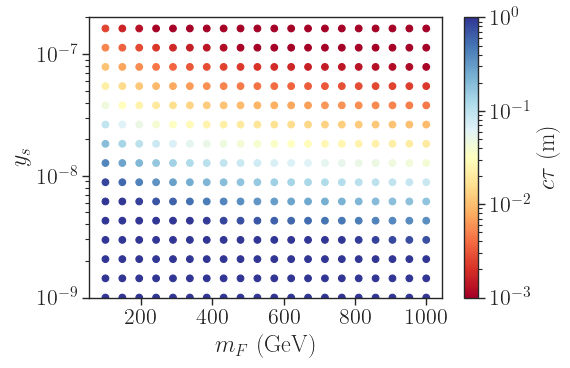

In [78]:
fig = plt.figure(figsize=(6,4))
yList = np.logspace(-9,-6,20)
mFlist = np.linspace(100,1000,20)
pts = np.array([[mF,0.1,y,0.3*lifetime(mF,0.1,y)] for mF,y in itertools.product(mFlist,yList)])
plt.scatter(pts[:,0],pts[:,2],c=pts[:,3],cmap=cm,norm=LogNorm(vmin=1e-3,vmax=1.0))
plt.xlabel(r'$m_{F}$ (GeV)')
plt.ylabel(r'$y_s$')
plt.yscale('log')
plt.ylim(1e-9,2e-7)
plt.colorbar(label=r'$c \tau$ (m)')
plt.tight_layout()
plt.show()


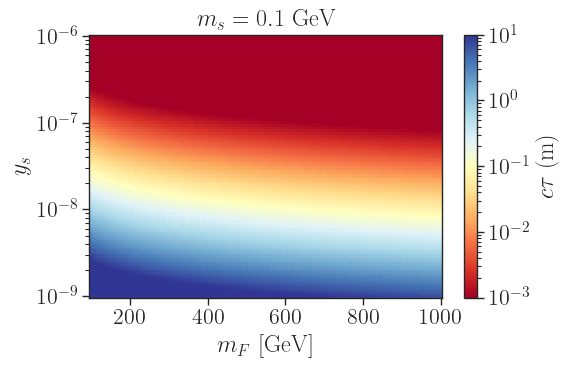

In [99]:
fig = plt.figure(figsize=(6,4))
yList = np.logspace(-9,-6,100)
mFlist = np.linspace(100,1000,100)
pts = np.array([[mF,0.1,y,0.3*lifetime(mF,0.1,y)] for mF,y in itertools.product(mFlist,yList)])

z = np.reshape(pts[:,3],(len(mFlist),len(yList)))
x,y  = np.meshgrid(mFlist,yList,indexing='ij')

# Use pcolormesh so each color is placed at the actual (x, y) grid point.
# imshow assumes linear pixel spacing and can misplace colors on log-scaled axes.
plt.pcolormesh(
    x,
    y,
    z,
    shading='auto',
    cmap=cm,
    norm=LogNorm(vmin=1e-3, vmax=10.0),
)

plt.colorbar(label=r'$c\tau$ (m)')
plt.xlabel(r'$m_{F}$ [GeV]')
plt.ylabel(r'$y_s$')
plt.yscale('log')
plt.title(r'$m_s = 0.1$ GeV')
plt.tight_layout()
plt.savefig('lifetime_mF_vs_y.png')
plt.show()


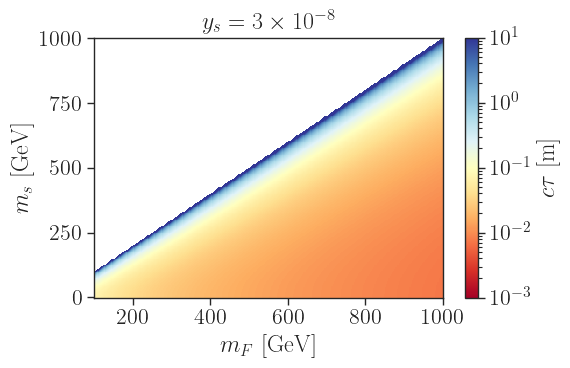

In [ ]:
fig = plt.figure(figsize=(6,5))
y = 3e-8
msList = np.linspace(1.0,1000.0,300)
mFlist = np.linspace(100,1000,300)
pts = np.array([[mF,ms,y,0.3*lifetime(mF,ms,y)] for mF,ms in itertools.product(mFlist,msList)])

z = np.reshape(pts[:,3],(len(mFlist),len(msList)))
x,y  = np.meshgrid(mFlist,msList,indexing='ij')

# Use pcolormesh so each color is placed at the actual (x, y) grid point.
# imshow assumes linear pixel spacing and can misplace colors on log-scaled axes.
plt.pcolormesh(
    x,
    y,
    z,
    shading='auto',
    cmap=cm,
    norm=LogNorm(vmin=1e-3, vmax=10.0),
)

plt.colorbar(label=r'$c\tau$ [m]')
plt.xlabel(r'$m_{F}$ [GeV]')
plt.ylabel(r'$m_s$ [GeV]')
plt.title(r'$y_s = 3 \times 10^{-8}$')
plt.tight_layout()
plt.savefig('lifetime_mF_vs_ms.png')
plt.show()


<Figure size 600x400 with 0 Axes>

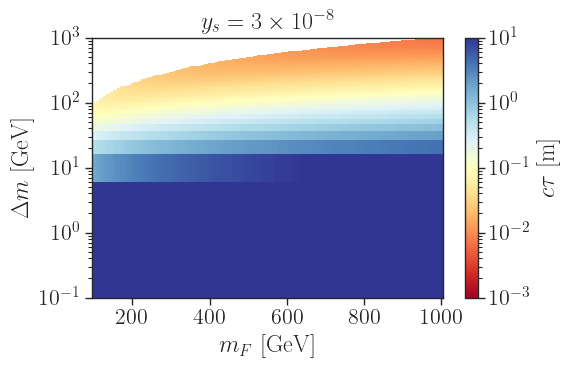

In [ ]:
plt.figure(figsize=(6,4))
fig = plt.figure(figsize=(6,4))
y = 3e-8
# msList = np.linspace(1.0,1000.0,100)
dmList = np.linspace(1.0,1000.0,100)
mFlist = np.linspace(100,1000,100)
pts = np.array([[mF,dm,y,0.3*lifetime(mF,mF-dm,y)] for mF,dm in itertools.product(mFlist,dmList)])

z = np.reshape(pts[:,3],(len(mFlist),len(dmList)))
x,y  = np.meshgrid(mFlist,dmList,indexing='ij')

# Use pcolormesh so each color is placed at the actual (x, y) grid point.
# imshow assumes linear pixel spacing and can misplace colors on log-scaled axes.
plt.pcolormesh(
    x,
    y,
    z,
    shading='auto',
    cmap=cm,
    norm=LogNorm(vmin=1e-3, vmax=10.0),
)

plt.colorbar(label=r'$c\tau$ [m]')
plt.xlabel(r'$m_{F}$ [GeV]')
plt.ylabel(r'$\Delta m$ [GeV]')
plt.yscale('log')
plt.ylim(1e-1,1e3)
plt.title(r'$y_s = 3 \times 10^{-8}$')
plt.tight_layout()
plt.savefig('lifetime_mF_vs_dm.png')
plt.show()
